In [245]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima.arima.utils import ndiffs
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import pmdarima as pm


> ## Part 1
>
> 1. **Load in the Zillow Home Value Index dataframe**
>    - Note: it is a large file and may take a minute to load
>
> 2. **Filter the 4 largest cities into a new dataframe**
>    - Tip: the `SizeRank` column has already ranked the cities by size
>    - The larger the city, the smaller the rank value
>    - Therefore the 4 largest cities would have rank values of `[0, 1, 2, 3]`
>
> 3. **Melt the data to long-form and prepare it for time series analysis**
>    - Convert the melted dates into `datetime` datatype
>    - Make the datetime column the index
>
> 4. **Resample the dataframe at monthly frequency, grouped by City**

In [246]:
# 1. Load in the Zillow Home Value Index dataframe
# load and check the dataset
df = pd.read_csv('zillow-home-analysis.csv')

# run the head
df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,2000-01-31,2000-02-29,...,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31
0,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,240543.592002,241823.720814,...,788722.182626,790761.938548,794310.149148,798157.535397,801287.722548,804731.423092,809721.417474,814827.637729,817470.616545,817744.531151
1,12447,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,224723.963733,225064.220279,...,950207.781249,952390.801416,955385.601555,958962.781245,962687.810453,963919.512365,962738.771664,958968.139935,954655.051793,951034.767271
2,39051,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,104967.981691,104941.312087,...,269193.149983,268497.231731,267915.477537,267632.682397,267682.123946,267621.300126,267308.755163,266697.043589,265925.840435,264951.507798
3,17426,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,150008.582202,150048.659977,...,315356.420691,316388.505150,317597.134759,318896.611991,320060.338523,321051.512214,322480.365442,323843.857744,325076.354628,325887.336287
4,6915,4,San Antonio,city,TX,TX,"San Antonio-New Braunfels, TX",Bexar County,101261.809291,101355.819240,...,254451.238789,254179.640331,253782.432289,253400.135839,253108.306133,252808.189935,252568.690663,252276.689533,251837.226672,251064.622912


In [247]:
# 2. Filter the 4 largest cities into a new dataframe
largest_cities = df[df['SizeRank'].isin([0, 1, 2, 3])]
largest_cities

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,2000-01-31,2000-02-29,...,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31
0,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,240543.592002,241823.720814,...,788722.182626,790761.938548,794310.149148,798157.535397,801287.722548,804731.423092,809721.417474,814827.637729,817470.616545,817744.531151
1,12447,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,224723.963733,225064.220279,...,950207.781249,952390.801416,955385.601555,958962.781245,962687.810453,963919.512365,962738.771664,958968.139935,954655.051793,951034.767271
2,39051,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,104967.981691,104941.312087,...,269193.149983,268497.231731,267915.477537,267632.682397,267682.123946,267621.300126,267308.755163,266697.043589,265925.840435,264951.507798
3,17426,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,150008.582202,150048.659977,...,315356.420691,316388.505150,317597.134759,318896.611991,320060.338523,321051.512214,322480.365442,323843.857744,325076.354628,325887.336287


In [248]:
# 3) a. Melt the data to long-form and prepare it for time series analysis
largest_cities_long = largest_cities.drop(columns=['RegionID']).melt(
    id_vars=['SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'Metro', 'CountyName'],
    var_name='Date',
    value_name='HomeValue'
)
largest_cities_long

,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,Date,HomeValue
0,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2000-01-31,240543.592002
1,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,2000-01-31,224723.963733
2,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,2000-01-31,104967.981691
3,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,2000-01-31,150008.582202
4,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2000-02-29,241823.720814
...,...,...,...,...,...,...,...,...,...
1263,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,2026-04-30,325076.354628
1264,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2026-05-31,817744.531151
1265,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,2026-05-31,951034.767271
1266,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,2026-05-31,264951.507798


In [249]:
# 3) b. Make the datetime column the index
largest_cities_long['Date'] = pd.to_datetime(largest_cities_long['Date'])
largest_cities_long.set_index('Date', inplace=True)
largest_cities_long

,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,HomeValue
Date,,,,,,,,
2000-01-31,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,240543.592002
2000-01-31,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,224723.963733
2000-01-31,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,104967.981691
2000-01-31,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,150008.582202
2000-02-29,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,241823.720814
...,...,...,...,...,...,...,...,...
2026-04-30,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,325076.354628
2026-05-31,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,817744.531151
2026-05-31,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,951034.767271


In [250]:
# 4.Resample the dataframe at monthly frequency, grouped by City
largest_cities_long = largest_cities_long.groupby('RegionName').resample('MS', include_groups=False).mean(numeric_only=True)

---

> ## Part 2
>
> 1. **Plot the home values for all 4 cities**
>    - Hint: use `unstack`
>    - Make sure to add a title and axis labels
>    - Reformat the y-axis ticks to use thousands of dollars with a "K" at the end (e.g. "200K", "400K", etc)
>      - Hint: use `FuncFormatter` from matplotlib
>
> 2. **Answer the following 2 questions using pandas:**
>
>    - **Which city had the highest Typical Home Value at the end of 2008? Which had the least?**
>      - Hint: you can use the unstacked dataframe or use `pd.IndexSlice` with the multiindex
>
>    - **How much did the home values change from November 2008 to December 2008 (in dollars)?**
>      - Hint: you can use `.diff()` to calculate the change in values

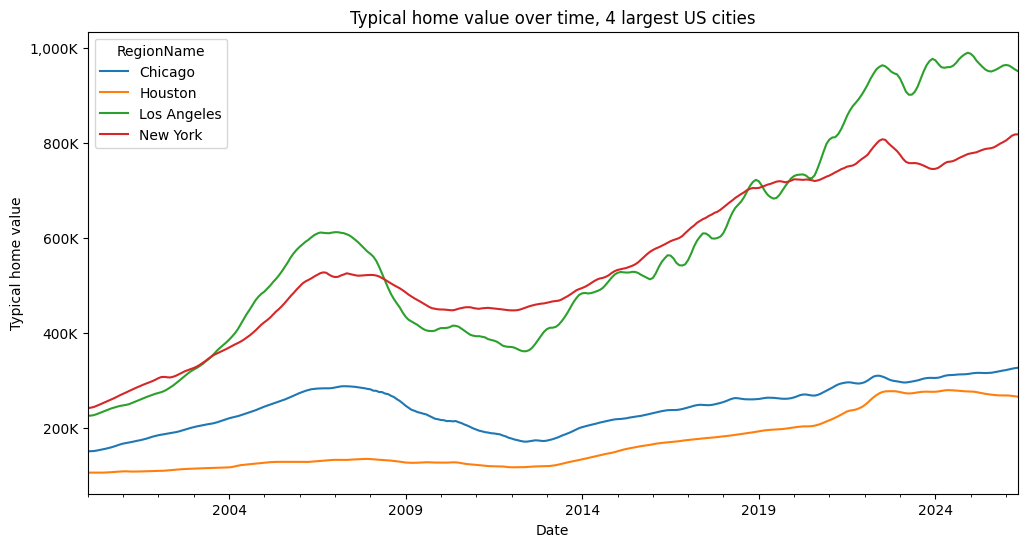

In [251]:
# 1. plot the home values for the 4 largest cities
ax = largest_cities_long.unstack(level=0)['HomeValue'].plot(figsize=(12, 6))

ax.set_title('Typical home value over time, 4 largest US cities')
ax.set_xlabel('Date')
ax.set_ylabel('Typical home value')

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:,.0f}K'))

In [252]:
# 2 a. Which city had the highest Typical Home Value at the end of 2008? Which had the least?
end_2008 = largest_cities_long.unstack(level=0)['HomeValue'].loc['2008-12-01']
print(f"Highest: {end_2008.idxmax()} (${end_2008.max():,.0f})")


Highest: New York ($489,304)


In [253]:
# 2 b. How much did the home values change from November 2008 to December 2008 (in dollars)?
city_values = largest_cities_long.unstack(level=0)['HomeValue']

change = city_values.diff().loc['2008-12-01']

change

RegionName
Chicago        -4849.951398
Houston         -900.948023
Los Angeles   -10802.695712
New York       -4076.231966
Name: 2008-12-01 00:00:00, dtype: float64

---

> ## `Time Series Models for Home Values`
>
> Your overall goal is to forecast the home values for the city with the highest home value in 2008 (New York) 6 months into the future (beyond the dataset).
>
> 1. **Filter the dataset to only include values starting in 2018**
>
> 2. **Check for and address null values**
>
> 3. **Decompose the time series to detect seasonality**
>    - Decide whether your model should or should not have a seasonal component
>
> 4. **Determine the time series model orders**
>    - Check the time series for stationarity
>      - Determine the number of differencing steps needed to make the data stationary
>    - Check the ACF/PACF plots of the differenced data to determine the orders
>
> 5. **Split the time series into training and test data**
>    - Remember we want to predict 6 months, and our data has been resampled to monthly
>
> 6. **Fit a manual ARIMA/SARIMA model based on the orders determined during your exploration**
>    - Make forecasts with your model
>    - Plot the forecasts versus the test data
>    - Obtain metrics for evaluation
>
> 7. **Tune with pmdarima's `auto_arima`**
>    - Fit a model on the training data with the best parameters from `auto_arima`
>    - Obtain metrics for evaluation
>    - Make forecasts with the `auto_arima` model
>    - Plot the forecasts versus the test data
>
> 8. **Select your final model**
>
> 9. **Make true future forecasts using the entire dataset (for dates beyond the entire time series)**
>    - Calculate the predicted net change in home value for the forecasted period as both:
>      - Raw values: the change in the final month of the forecast vs. the first month
>      - The raw delta converted into a percent change
>
> ### Answer the following questions in a Markdown cell
>
> - What is the predicted home value in New York City 6 months into the future (beyond the dataset)?
> - What is the percent change in home values in New York City by the end of the 6-month forecast (beyond the dataset)?

In [254]:
# check the columns of the unstacked dataframe
largest_cities_long.unstack(level=0)['HomeValue'].columns

Index(['Chicago', 'Houston', 'Los Angeles', 'New York'], dtype='object', name='RegionName')

In [255]:
# select the home values for New York City
ny = largest_cities_long.loc['New York']

# run the head of the New York City home values
ny.head()

,SizeRank,HomeValue
Date,,
2000-01-01,0.0,240543.592002
2000-02-01,0.0,241823.720814
2000-03-01,0.0,243134.159158
2000-04-01,0.0,245655.668298
2000-05-01,0.0,248215.143772


In [256]:
# 1. filter the dataset to only include data from 2018-01-01 and later
ny = largest_cities_long.loc['New York'].loc['2018-01-01':]

# check the head of the filtered dataset
ny.head()

,SizeRank,HomeValue
Date,,
2018-01-01,0.0,663783.918468
2018-02-01,0.0,668897.194236
2018-03-01,0.0,674043.288999
2018-04-01,0.0,678526.969983
2018-05-01,0.0,683775.944498


In [257]:
# 2. check for and address null values 
ny.isna().sum()

SizeRank     0
HomeValue    0
dtype: int64

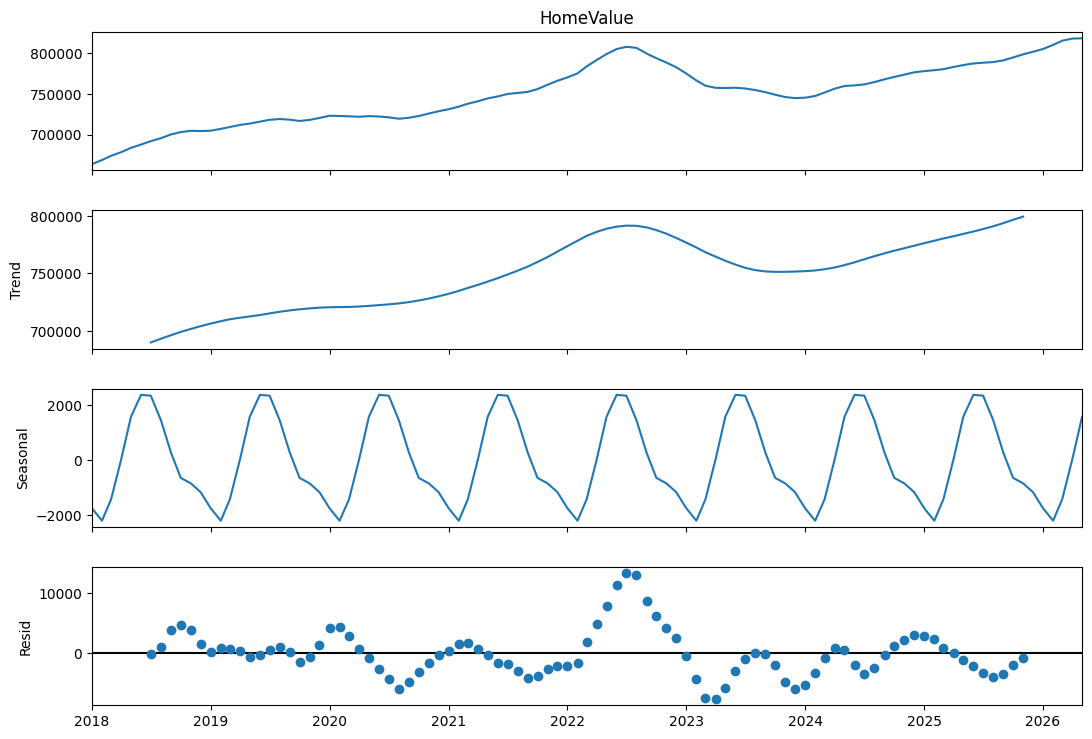

In [258]:
# 3.Decompose the time series to detect seasonality
result = seasonal_decompose(ny['HomeValue'], model='additive', period=12)

# plot the decomposed time series
fig = result.plot()
fig.set_size_inches(12, 8)

### **Does the model have a seasonal component?**
> Yes it has a regular seasonal component. 

In [259]:
# 4. Check for stationarity using the Augmented Dickey-Fuller test
def get_adfuller_results(series, alpha=0.05):
    result = adfuller(series.dropna())
    p_value = result[1]
    stationary = p_value < alpha
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value:       {p_value:.4f}")
    print(f"Stationary:    {stationary} (alpha={alpha})")
    return stationary

In [260]:
# Run ADF on the original series
get_adfuller_results(ny['HomeValue'])

ADF Statistic: -1.3285
p-value:       0.6160
Stationary:    False (alpha=0.05)


np.False_

In [261]:
# Determine the number of differences needed to make the series stationary
n_diffs = ndiffs(ny['HomeValue'], test='adf')
print("ndiffs:", n_diffs)

ndiffs: 1


In [262]:
# Confirm with ADF after applying n_diffs differences
diff = ny['HomeValue'].copy()
for _ in range(n_diffs):
    diff = diff.diff()
diff = diff.dropna()

print(f"=== After {n_diffs} difference(s) ===")
get_adfuller_results(diff)

=== After 1 difference(s) ===
ADF Statistic: -2.4770
p-value:       0.1212
Stationary:    False (alpha=0.05)


np.False_

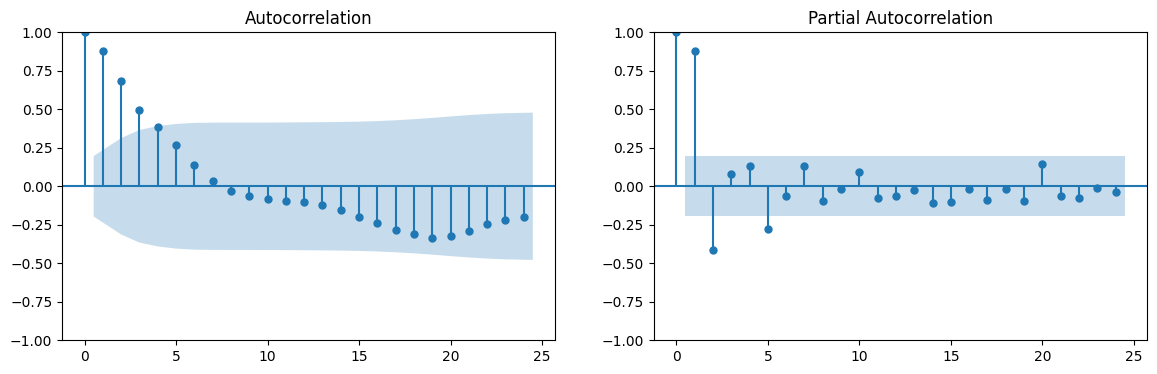

In [263]:
# Check ACF/PACF of the differenced data to determine the orders
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff, lags=24, ax=axes[0])
plot_pacf(diff, lags=24, ax=axes[1])
plt.show()

In [264]:
# 5. Split the time series into training and test data (Remember we want to predict 6 months, and our data has been resampled to monthly)
ny_series = ny['HomeValue']

# Split into training and test data
train = ny_series[:-6]
test = ny_series[-6:]

In [265]:
# 6. Fit a manual SARIMA model based on the orders from exploration
order = (1, 1, 0)
seasonal_order = (1, 0, 0, 12)

model = SARIMAX(train, order=order, seasonal_order=seasonal_order)
results = model.fit(disp=False)
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                          HomeValue   No. Observations:                   95
Model:             SARIMAX(1, 1, 0)x(1, 0, 0, 12)   Log Likelihood               -1028.143
Date:                            Mon, 29 Jun 2026   AIC                           2062.285
Time:                                    15:34:28   BIC                           2069.915
Sample:                                01-01-2018   HQIC                          2065.367
                                     - 11-01-2025                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0162      0.002      7.555      0.000       0.012       0.020
ar.S.L12       0.0010      0.018      0.053      0.958      -0.035       0.037
sigma2       2.18e+06   5.55e+04     39.303      0.000    2.07e+06    2.29e+06
===================================================================================
Ljung-Box (L1) (Q):                  70.14   Jarque-Bera (JB):                15.66
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.88   Skew:                            -0.85
Prob(H) (two-sided):                  0.73   Kurtosis:                         4.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [266]:
# Make forecasts with your model (6 months to match the test set)
forecast = results.get_forecast(steps=6)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()
forecast_mean

2025-12-01    798222.493620
2026-01-01    798224.896417
2026-02-01    798226.052535
2026-03-01    798227.261614
2026-04-01    798229.889000
2026-05-01    798232.163438
Freq: MS, Name: predicted_mean, dtype: float64

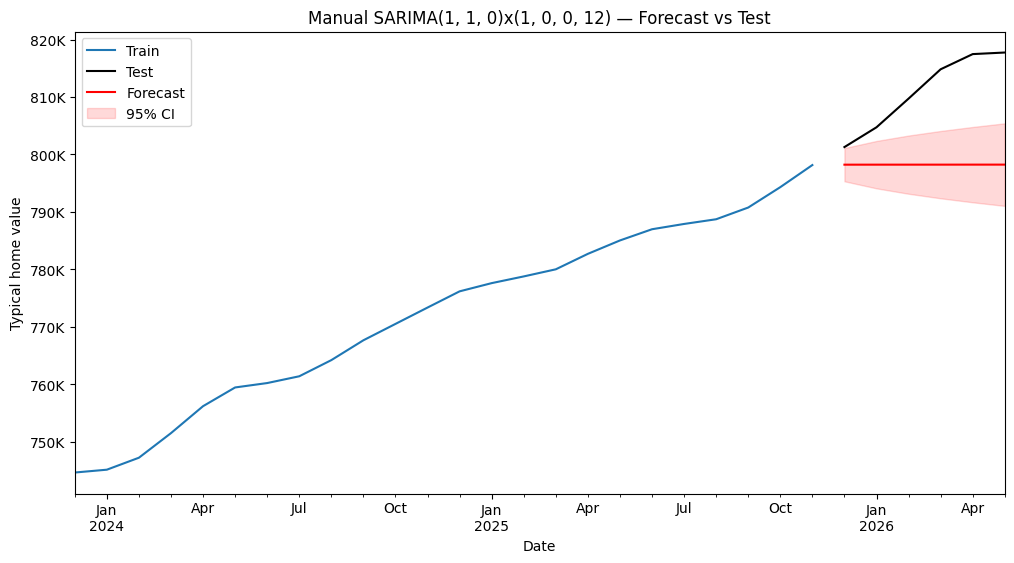

In [267]:
# Plot the forecasts versus the test data
fig, ax = plt.subplots(figsize=(12, 6))

train[-24:].plot(ax=ax, label='Train')
test.plot(ax=ax, label='Test', color='black')
forecast_mean.plot(ax=ax, label='Forecast', color='red')
ax.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                color='red', alpha=0.15, label='95% CI')

ax.set_title(f'Manual SARIMA{order}x{seasonal_order} — Forecast vs Test')
ax.set_xlabel('Date')
ax.set_ylabel('Typical home value')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:,.0f}K'))
ax.legend()
plt.show()

In [268]:
# Obtain metrics for evaluation
mae = mean_absolute_error(test, forecast_mean)
rmse = np.sqrt(mean_squared_error(test, forecast_mean))
mape = mean_absolute_percentage_error(test, forecast_mean) * 100

print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"MAPE: {mape:.2f}%")

MAE:  $12,737
RMSE: $14,203
MAPE: 1.56%


In [269]:
# 7. Tune with pmdarima's auto_arima
auto_model = pm.auto_arima(
    train,
    seasonal=True, m=12,
    d=1, D=0,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
auto_model.summary()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1789.601, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1797.656, Time=0.23 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1796.103, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1804.460, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=1791.473, Time=0.06 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=1791.472, Time=0.03 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=1793.478, Time=0.15 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1795.643, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1794.195, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=1782.600, Time=0.15 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=1807.013, Time=0.33 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=2006.418, Time=0.20 sec
 ARIMA(1,1,1)(1,0,1)[12] intercept   : AIC=2008.420, Time=0.36 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : AIC=1784.212, Time=0.14 sec
 ARIMA(1,1,2)(0,0,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   95
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -887.300
Date:                Mon, 29 Jun 2026   AIC                           1782.600
Time:                        15:34:31   BIC                           1792.773
Sample:                    01-01-2018   HQIC                          1786.709
                         - 11-01-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    239.6244    312.766      0.766      0.444    -373.385     852.634
ar.L1          0.7958      0.243      3.269      0.001       0.319       1.273
ma.L1         -0.7853      0.246     -3.199      0.001      -1.267      -0.304
sigma2       9.17e+06      0.004   2.25e+09      0.000    9.17e+06    9.17e+06
===================================================================================
Ljung-Box (L1) (Q):                  73.21   Jarque-Bera (JB):                18.02
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.93   Skew:                            -0.82
Prob(H) (two-sided):                  0.07   Kurtosis:                         4.38
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.73e+26. Standard errors may be unstable.
"""

In [270]:
# Fit a SARIMAX model on training data with the best parameters from auto_arima
best_order = auto_model.order
best_seasonal_order = auto_model.seasonal_order
print("Best order:", best_order, "| Seasonal:", best_seasonal_order)

auto_results = SARIMAX(train, order=best_order,
                       seasonal_order=best_seasonal_order).fit(disp=False)
auto_results.summary()

Best order: (1, 1, 1) | Seasonal: (0, 0, 0, 12)


C:\Users\noman\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              HomeValue   No. Observations:                   95
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -890.575
Date:                Mon, 29 Jun 2026   AIC                           1787.149
Time:                        15:46:49   BIC                           1794.779
Sample:                    01-01-2018   HQIC                          1790.231
                         - 11-01-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9563      0.029     33.172      0.000       0.900       1.013
ma.L1         -0.9488      0.034    -27.649      0.000      -1.016      -0.882
sigma2      1.117e+07   3.16e-10   3.53e+16      0.000    1.12e+07    1.12e+07
===================================================================================
Ljung-Box (L1) (Q):                  74.72   Jarque-Bera (JB):                 6.83
Prob(Q):                              0.00   Prob(JB):                         0.03
Heteroskedasticity (H):               2.26   Skew:                            -0.53
Prob(H) (two-sided):                  0.03   Kurtosis:                         3.78
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.66e+32. Standard errors may be unstable.
"""

In [271]:
# Make forecasts with the auto_arima model (6 months)
auto_forecast = auto_results.get_forecast(steps=6)
auto_forecast_mean = auto_forecast.predicted_mean
auto_conf_int = auto_forecast.conf_int()
auto_forecast_mean

2025-12-01    798401.555467
2026-01-01    798634.899757
2026-02-01    798858.035328
2026-03-01    799071.408807
2026-04-01    799275.447283
2026-05-01    799470.559157
Freq: MS, Name: predicted_mean, dtype: float64

In [272]:
# Obtain metrics for evaluation
auto_mae = mean_absolute_error(test, auto_forecast_mean)
auto_rmse = np.sqrt(mean_squared_error(test, auto_forecast_mean))
auto_mape = mean_absolute_percentage_error(test, auto_forecast_mean) * 100

print(f"MAE:  ${auto_mae:,.0f}")
print(f"RMSE: ${auto_rmse:,.0f}")
print(f"MAPE: {auto_mape:.2f}%")

MAE:  $12,012
RMSE: $13,396
MAPE: 1.48%


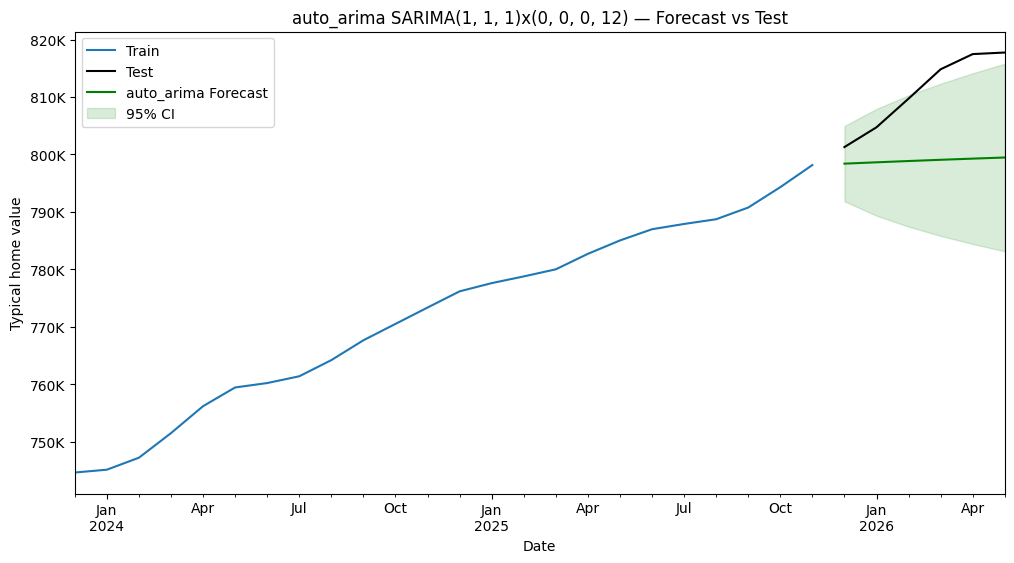

In [273]:
# Plot the forecasts versus the test data
fig, ax = plt.subplots(figsize=(12, 6))

train[-24:].plot(ax=ax, label='Train')
test.plot(ax=ax, label='Test', color='black')
auto_forecast_mean.plot(ax=ax, label='auto_arima Forecast', color='green')
ax.fill_between(auto_conf_int.index, auto_conf_int.iloc[:, 0], auto_conf_int.iloc[:, 1],
                color='green', alpha=0.15, label='95% CI')

ax.set_title(f'auto_arima SARIMA{best_order}x{best_seasonal_order} — Forecast vs Test')
ax.set_xlabel('Date')
ax.set_ylabel('Typical home value')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:,.0f}K'))
ax.legend()
plt.show()

In [274]:
# 8. Select your final model
# Compare the test-set metrics of both models and keep the lower-error one.
print("Manual SARIMA(1,1,0)(1,0,0,12):")
print(f"  MAE: ${mae:,.0f} | RMSE: ${rmse:,.0f} | MAPE: {mape:.2f}%")
print(f"\nauto_arima SARIMA{best_order}x{best_seasonal_order}:")
print(f"  MAE: ${auto_mae:,.0f} | RMSE: ${auto_rmse:,.0f} | MAPE: {auto_mape:.2f}%")

Manual SARIMA(1,1,0)(1,0,0,12):
  MAE: $12,737 | RMSE: $14,203 | MAPE: 1.56%

auto_arima SARIMA(1, 1, 1)x(0, 0, 0, 12):
  MAE: $12,012 | RMSE: $13,396 | MAPE: 1.48%


> ### Final Model

Comparing test-set performance, the **[manual / auto_arima]** model had the lower error (MAPE = [..]%, RMSE = [..]), so it is selected as the final model: **SARIMA([p],[d],[q])([P],[D],[Q],12)**.

In [275]:
# 9. Refit the FINAL model on the ENTIRE dataset (train + test), then forecast 6 months beyond it
final_order = (1, 1, 0)            # <-- replace with your chosen final orders
final_seasonal_order = (1, 0, 0, 12)

final_model = SARIMAX(ny_series, order=final_order,
                      seasonal_order=final_seasonal_order).fit(disp=False)

future_forecast = final_model.get_forecast(steps=6)
future_mean = future_forecast.predicted_mean
future_conf_int = future_forecast.conf_int()
future_mean

2026-06-01    817751.230805
2026-07-01    817752.344867
2026-08-01    817753.271096
2026-09-01    817755.576394
2026-10-01    817759.586487
2026-11-01    817763.934699
Freq: MS, Name: predicted_mean, dtype: float64

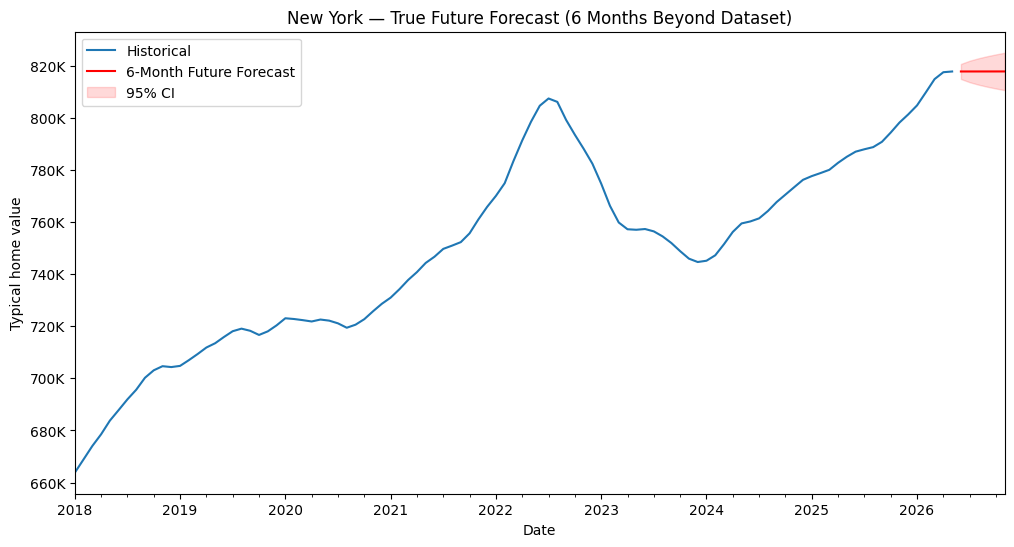

In [276]:
# Plot the true future forecast against the full history
fig, ax = plt.subplots(figsize=(12, 6))

ny_series.plot(ax=ax, label='Historical')
future_mean.plot(ax=ax, label='6-Month Future Forecast', color='red')
ax.fill_between(future_conf_int.index, future_conf_int.iloc[:, 0], future_conf_int.iloc[:, 1],
                color='red', alpha=0.15, label='95% CI')

ax.set_title('New York — True Future Forecast (6 Months Beyond Dataset)')
ax.set_xlabel('Date')
ax.set_ylabel('Typical home value')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:,.0f}K'))
ax.legend()
plt.show()

In [277]:
# Calculate the predicted net change over the forecast period
first_month = future_mean.iloc[0]
last_month = future_mean.iloc[-1]

# Raw change: final forecast month vs. first forecast month
raw_change = last_month - first_month

# Percent change
pct_change = (raw_change / first_month) * 100

print(f"First forecast month ({future_mean.index[0].date()}): ${first_month:,.0f}")
print(f"Last forecast month  ({future_mean.index[-1].date()}): ${last_month:,.0f}")
print(f"\nRaw net change:     ${raw_change:,.0f}")
print(f"Percent change:     {pct_change:.2f}%")

First forecast month (2026-06-01): $817,751
Last forecast month  (2026-11-01): $817,764

Raw net change:     $13
Percent change:     0.00%


### Forecast Questions

| Question | Answer |
|---|---|
| Predicted home value 6 months out (Nov 2026) | **$817,764** |
| Percent change over the 6-month forecast | **+0.002%** (≈ flat, +$13) |

The model projects an essentially flat trajectory over the next six months — the typical New York home value holds at roughly **$817.8K**, with a negligible net change of about **+$13 (+0.002%)** from the first to the last forecast month.